In [19]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
import json
import matplotlib.pyplot as plt
import numpy as np
import statistics
import sys
import seaborn as sns
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()

# Analyzing finetuning process

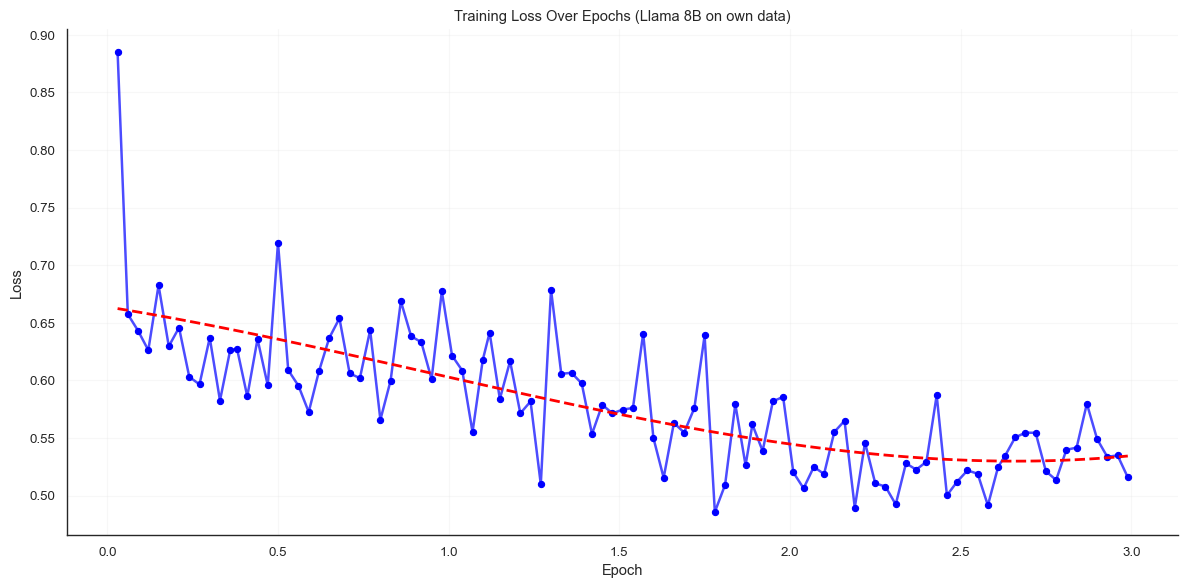

Initial loss: 0.8851
Final loss: 0.5158
Minimum loss: 0.4858 at epoch 1.78
Loss reduction: 45.11%


In [12]:
# Read the finetuning_output.jsonl file
output_file = "finetuning_logs/llama8b_single_log1.jsonl"
losses = []
epochs = []

with open(output_file, 'r') as f:
    for line in f:
        try:
            data = json.loads(line)
            losses.append(data['loss'])
            epochs.append(data['epoch'])
        except json.JSONDecodeError:
            print(f"Error parsing line: {line}")
        except KeyError:
            print(f"Missing key in line: {line}")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(epochs, losses, 'b-', alpha=0.7)
plt.scatter(epochs, losses, c='blue', s=20)

# Add smoothed trend line
if len(losses) > 10:
    z = np.polyfit(epochs, losses, 3)
    p = np.poly1d(z)
    plt.plot(epochs, p(epochs), 'r--', linewidth=2)

plt.title('Training Loss Over Epochs (Llama 8B on own data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Add annotations for min and max loss
min_loss = min(losses)
min_epoch = epochs[losses.index(min_loss)]
max_loss = max(losses)
max_epoch = epochs[losses.index(max_loss)]

'''
plt.annotate(f'Min Loss: {min_loss:.4f}', 
             xy=(min_epoch, min_loss),
             xytext=(min_epoch, min_loss+0.05),
             arrowprops=dict(facecolor='green', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))

plt.annotate(f'Max Loss: {max_loss:.4f}', 
             xy=(max_epoch, max_loss),
             xytext=(max_epoch, max_loss-0.1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
'''


plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Minimum loss: {min_loss:.4f} at epoch {min_epoch:.2f}")
print(f"Loss reduction: {((losses[0] - min_loss) / losses[0] * 100):.2f}%")


## Check how much data is >2048 tokens

In [22]:
# Load the tokenizer for Llama
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

# Path to the jsonl file
#file_path = "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_all_Llama.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Small/Other/dolly_train_all_multi.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_all_Llama.jsonl"
file_path = "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_all_multi.jsonl"

# Check if the file exists
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
else:
    # Count total entries and those exceeding token limit
    total_entries = 0
    exceeding_limit = 0
    max_tokens = 0
    total_instruction_tokens_exceeding = 0
    instruction_token_lengths = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            total_entries += 1
            data = json.loads(line)
            
            # Find the appropriate response key (not using response_human)
            response_key = next((key for key in data.keys() 
                               if key.startswith("response_") and key != "response_human"), 
                              "response")  # fallback to "response" if no matching key found
            
            # Tokenize instruction and combined text separately
            instruction_text = data['instruction']
            instruction_tokens = tokenizer.encode(instruction_text)
            instruction_token_count = len(instruction_tokens)
            
            combined_text = f"You are a helpful assistant.\nInstruction: {data['instruction']}\nResponse: {data[response_key]}"
            tokens = tokenizer.encode(combined_text)
            token_count = len(tokens)
            
            # Update max token count
            max_tokens = max(max_tokens, token_count)
            
            # Check if token count exceeds limit
            if token_count > 2048:
                exceeding_limit += 1
                total_instruction_tokens_exceeding += instruction_token_count
                instruction_token_lengths.append(instruction_token_count)
    
    # Calculate percentages and averages
    percentage = (exceeding_limit / total_entries) * 100 if total_entries > 0 else 0
    avg_instruction_tokens = total_instruction_tokens_exceeding / exceeding_limit if exceeding_limit > 0 else 0
    median_instruction_tokens = statistics.median(instruction_token_lengths) if instruction_token_lengths else 0
    
    print(f"Total entries: {total_entries}")
    print(f"Entries exceeding 2048 tokens: {exceeding_limit} ({percentage:.2f}%)")
    print(f"Maximum token count found: {max_tokens}")
    print(f"Average instruction length for entries exceeding limit: {avg_instruction_tokens:.2f} tokens")
    print(f"Median instruction length for entries exceeding limit: {median_instruction_tokens:.2f} tokens")


Total entries: 13509
Entries exceeding 2048 tokens: 30 (0.22%)
Maximum token count found: 6216
Average instruction length for entries exceeding limit: 2863.77 tokens
Median instruction length for entries exceeding limit: 2448.00 tokens
